# Simulating stuff with synthpop and ocelot!

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import copy
from astropy.coordinates import (
    SkyCoord,
    CylindricalRepresentation,
    CylindricalDifferential,
)
from astropy import units as u
from astroquery.gaia import Gaia

# import gaianir_open_clusters  # noqa: F401
from gaianir_open_clusters.cluster_model import GaiaNIRObservationModel
from gaianir_open_clusters.population import simulate_region
from gaianir_open_clusters.gaia_nir_config import GAIANIR_ANGULAR_RESOLUTION
from gaianir_open_clusters.crowding import apply_cluster_crowding
from ocelot.simulate import (
    SimulatedCluster,
    SimulatedClusterParameters,
    SimulatedClusterModels,
)
from ocelot.model.observation import (
    GaiaDR3ObservationModel,
    GenericSubsampleSelectionFunction,
)
from scipy.stats import poisson, ecdf
from scipy.interpolate import interp1d
from sklearn.neighbors import NearestNeighbors


In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


/home/emily/code/gaianir-open-clusters/.venv/lib/python3.13/site-packages/pydantic/_internal/_config.py:386: UserWarning: Valid config keys have changed in V2:
* 'keep_untouched' has been renamed to 'ignored_types'
  warnings.warn(message, UserWarning)
 7136 - Location or solid_angle_sr are not  defined in the settings! Can not run main() or process_all()


Loading pixel_info ...
Loading samples ...
Loading best_fit ...
Replacing NaNs in reliable distance estimates ...
Sorting pixel_info ...
Extracting hp_idx_sorted and data_idx at each nside ...
  nside = 64
  nside = 128
  nside = 256
  nside = 512
  nside = 1024
t = 19.016 s
  pix_info:   0.537 s
   samples:   2.828 s
      best:   2.972 s
       nan:   0.035 s
      sort:  12.536 s
       idx:   0.107 s
Loading meta pixel info...
Meta pixel info loaded!


## Region sim!

In [ ]:
l = 10
b = 0

In [3]:
region, crowding_metadata = simulate_region(l, b, 1/60**2, minimum_stars=10000)

Initializing populations for first time...
Simulating region... (attempt 1, area 1.000 arcmin^2)
  now adding photometry for 55857 stars...
Success! Calculating astrometry for 34185 remaining stars.
Applying crowding.
Standardizing columns.


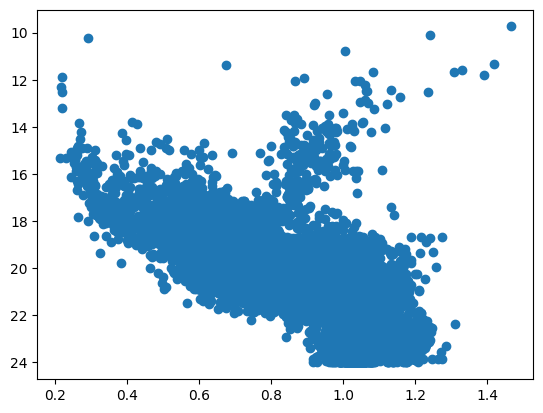

In [ ]:
plt.scatter(region['gaianir_j'] - region['gaianir_k'], region['gaianir_n'])
plt.gca().invert_yaxis()

## Cluster sim!

In [4]:
position = SkyCoord(
    l=l * u.deg,
    b=b * u.deg,
    distance=10000 * u.pc,
    pm_l_cosb=10 * u.mas / u.yr,
    pm_b=0 * u.mas / u.yr,
    radial_velocity=0 * u.km / u.s,
    frame="galactic",
)

parameters = SimulatedClusterParameters(
    position=position,
    mass=1000,
    log_age=9,
    metallicity=0.0,
    extinction=5.0,
    r_core=2,
    r_tidal=10,
    virial_ratio=0.5
)

In [ ]:
Gaia.ROW_LIMIT = 10000
query = Gaia.cone_search(parameters.position, radius=0.5 * u.deg)
gaia_data = query.get_results().to_pandas().rename(columns={"SOURCE_ID": "source_id"})

In [5]:
models = SimulatedClusterModels(
    observations=[
        GaiaNIRObservationModel(
            mission_class="GaiaNIR-L", years=10, maximum_magnitude=23
        ),
        GaiaNIRObservationModel(
            mission_class="GaiaNIR-M", years=10, maximum_magnitude=23
        ),
        GaiaNIRObservationModel(
            mission_class="Gaia",
            years=10,
            maximum_magnitude=21,
            combined_astrometry=False,
        ),
        GaiaNIRObservationModel(
            mission_class="Gaia",
            years=5,
            maximum_magnitude=21,
            combined_astrometry=False,
        ),
        # GaiaDR3ObservationModel(
        #     representative_stars=gaia_data, overestimate_bp_rp_fluxes=False
        # ),
    ]
)

In [6]:
cluster = SimulatedCluster(random_seed=42, parameters=parameters, models=models)
cluster.make()

In [7]:
cluster.observations.keys()

dict_keys(['gaianir-l-10-(combined)', 'gaianir-m-10-(combined)', 'gaia-10', 'gaia-5'])

In [8]:
cluster.observations['gaianir-l-10-(combined)'].keys()

Index(['simulated_id', 'cluster_id', 'simulated_star', 'mass_initial', 'mass',
       'temperature', 'luminosity', 'log_g', 'gaia_dr3_g_true',
       'gaia_dr3_bp_true', 'gaia_dr3_rp_true', 'companions', 'mass_ratio',
       'period', 'eccentricity', 'simulated_id_primary', 'ra', 'dec', 'l', 'b',
       'pmra', 'pmdec', 'parallax', 'pmra_true', 'pmdec_true', 'parallax_true',
       'radial_velocity_true', 'extinction', 'radius', 'gaianir_n_true',
       'gaianir_r_true', 'gaianir_j_true', 'gaianir_h_true', 'gaianir_k_true',
       'extinction_gaianir_n', 'extinction_gaianir_r', 'extinction_gaianir_j',
       'extinction_gaianir_h', 'extinction_gaianir_k', 'gaianir_n',
       'gaianir_r', 'gaianir_j', 'gaianir_h', 'gaianir_k',
       'unresolved_companions', 'g_effective_gaia', 'pmra_error',
       'pmdec_error', 'parallax_error',
       'selection_probability_GaiaNIRSelectionFunction',
       'selection_probability'],
      dtype='str')

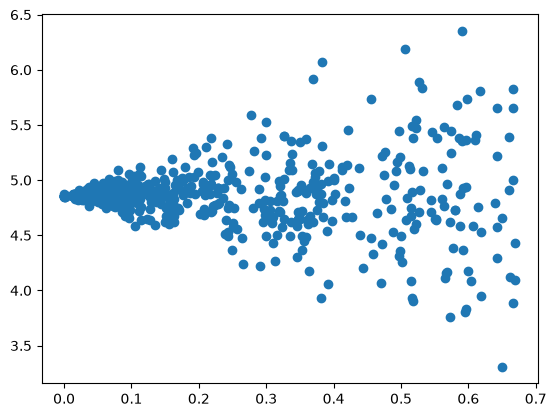

In [9]:
plt.scatter(
    cluster.observations["gaianir-l-10-(combined)"]["pmra_error"],
    cluster.observations["gaianir-l-10-(combined)"]["pmra"],
)

In [61]:
pd.DataFrame(parameters.to_dict(), index=[0]).drop(columns="position")

,mass,log_age,metallicity,r_core,r_tidal,extinction,differential_extinction,minimum_stars,virial_ratio,eta_virial_ratio,...,velocity_dispersion_1d,n_stars,ra,dec,l,b,distance,pmra,pmdec,radial_velocity
0,1000,9,0.0,2,10,5.0,0.0,1,0.5,10.0,...,424.980637,0,271.940422,-20.290029,10.0,0.0,10000.0,4.861497,8.738755,1.724573e-11


In [27]:
cluster.observations['gaianir-l-10-(combined)']

,simulated_id,cluster_id,simulated_star,mass_initial,mass,temperature,luminosity,log_g,gaia_dr3_g_true,gaia_dr3_bp_true,...,gaianir_j,gaianir_h,gaianir_k,unresolved_companions,g_effective_gaia,pmra_error,pmdec_error,parallax_error,selection_probability_GaiaNIRSelectionFunction,selection_probability
0,2103,0,True,0.480388,0.480388,3510.218026,0.029364,4.784004,24.321667,25.504106,...,23.114938,22.185985,21.651869,0,27.858609,0.669475,0.577133,2.308533,1.0,1.0
1,1712,0,True,0.480571,0.480571,3510.651997,0.029402,4.783818,24.319910,25.501991,...,23.113696,22.184687,21.650537,0,27.856893,0.668474,0.576271,2.305083,1.0,1.0
2,1222,0,True,0.480917,0.480917,3511.476075,0.029476,4.783464,24.316575,25.497977,...,23.111337,22.182223,21.648010,0,27.853634,0.666571,0.574630,2.298520,1.0,1.0
3,2426,0,True,0.480959,0.480959,3511.574114,0.029484,4.783422,24.316178,25.497499,...,23.111057,22.181930,21.647709,0,27.853246,0.666344,0.574435,2.297738,1.0,1.0
4,1055,0,True,0.481040,0.481040,3511.768233,0.029502,4.783339,24.315392,25.496553,...,23.110501,22.181350,21.647114,0,27.852479,0.665895,0.574048,2.296190,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
590,3389,0,True,2.264398,2.262575,4972.893504,69.706278,2.687910,15.157335,15.628850,...,15.136265,14.316533,13.863810,0,18.826338,0.000396,0.000347,0.014966,1.0,1.0
591,3295,0,True,2.275434,2.273698,4943.760873,74.933750,2.648653,15.085364,15.563422,...,15.048444,14.223374,13.767740,0,18.751809,0.000378,0.000331,0.014267,1.0,1.0
592,3496,0,True,2.276035,2.274305,4942.177226,75.229811,2.646513,15.081440,15.559854,...,15.043652,14.218292,13.762500,0,18.747746,0.000377,0.000330,0.014227,1.0,1.0
593,3401,0,True,2.280275,2.278680,4933.237593,77.184007,2.633137,15.055770,15.536106,...,15.012909,14.185927,13.729239,0,18.721290,0.000370,0.000324,0.013968,1.0,1.0


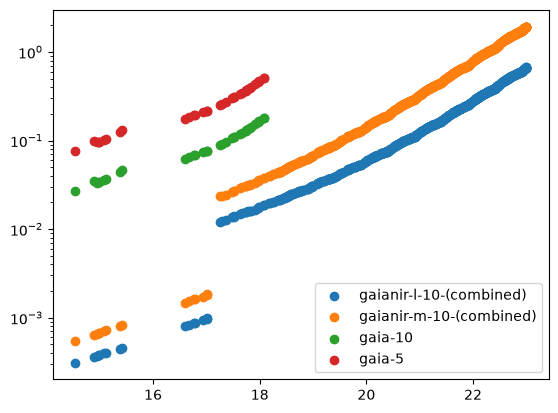

In [33]:
for observation_name, observation in cluster.observations.items():
    plt.scatter(observation['gaianir_n'], observation['pmra_error'], label=observation_name)

plt.legend()
plt.yscale("log")

## Various diagnostic plots

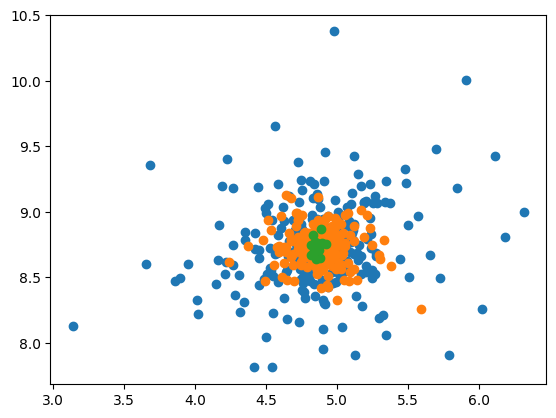

In [10]:
obs_m = cluster.observations['gaianir-m-10-(combined)'].query("gaianir_n < 22")
obs_l = cluster.observations['gaianir-l-10-(combined)'].query("gaianir_n < 22")
# obs_g = cluster.observations['gaia-10'].query("g_effective_gaia < 20")
obs_dr3 = cluster.observations['gaia_dr3'].query("gaia_dr3_g < 20")


plt.scatter(obs_m['pmra'], obs_m['pmdec'])
plt.scatter(obs_l['pmra'], obs_l['pmdec'])
# plt.scatter(obs_g['pmra'], obs_g['pmdec'])
plt.scatter(obs_dr3['pmra'], obs_dr3['pmdec'])

[None]

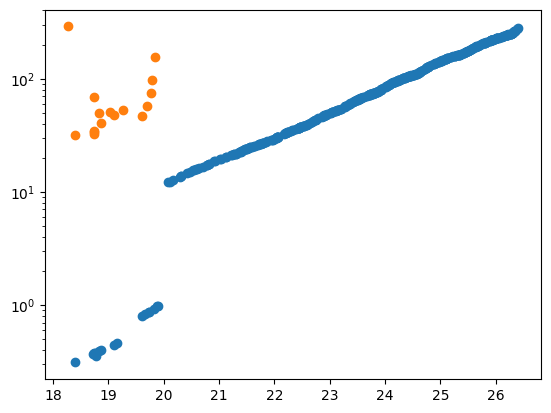

In [11]:
plt.scatter(obs_l['g_effective_gaia'], obs_l['pmra_error']*1000)
plt.scatter(obs_dr3['gaia_dr3_g'], obs_dr3['pmra_error']*1000)
plt.gca().set(yscale="log")

(array([11.,  2.,  1.,  0.,  1.,  0.,  0.,  0.,  0.,  1.]),
 array([0.0319135 , 0.05760601, 0.08329852, 0.10899103, 0.13468355,
        0.16037604, 0.18606856, 0.21176109, 0.23745358, 0.2631461 ,
        0.2888386 ]),
 <BarContainer object of 10 artists>)

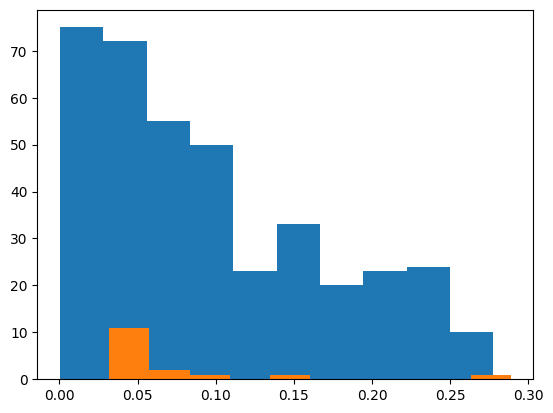

In [12]:
plt.hist(obs_l['pmra_error'])
plt.hist(obs_dr3['pmra_error'])
# plt.gca().set(yscale="log")

[Text(0.5, 0, 'G'), Text(0, 0.5, 'pmra error (uas/yr)')]

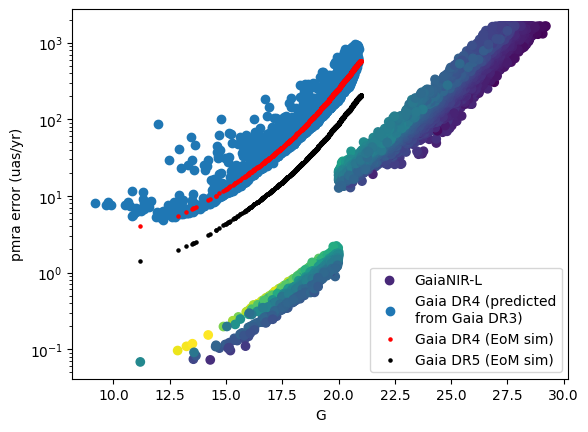

In [13]:
plt.scatter(
    region["gaia_dr3_g"],
    region["pmra_error_gaianir-l_combined"] * 1000,
    c=region["logTeff"],
    label="GaiaNIR-L",
)
plt.gca().set(yscale="log")

plt.scatter(
    gaia_data["phot_g_mean_mag"], gaia_data["pmra_error"] * 1000 / (2 * np.sqrt(2)), label="Gaia DR4 (predicted\nfrom Gaia DR3)"
)
plt.scatter(region["gaia_dr3_g"], region["pmra_error_gaia_dr4"] * 1000, c="r", s=5, label="Gaia DR4 (EoM sim)")
plt.scatter(region["gaia_dr3_g"], region["pmra_error_gaia_dr5"] * 1000, c="k", s=5, label="Gaia DR5 (EoM sim)")
plt.legend()
plt.gca().set(xlabel="G", ylabel="pmra error (uas/yr)")

[Text(0.5, 0, 'N'), Text(0, 0.5, 'pmra error (uas/yr)')]

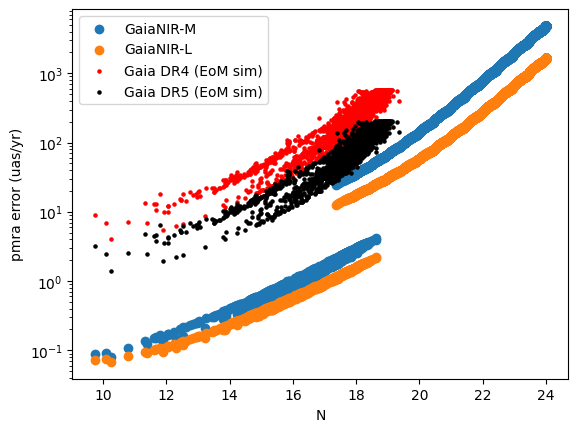

In [14]:
plt.scatter(
    region["gaianir_n"],
    region["pmra_error_gaianir-m_combined"] * 1000,
    # c=region["logTeff"],
    label="GaiaNIR-M",
)
plt.scatter(
    region["gaianir_n"],
    region["pmra_error_gaianir-l_combined"] * 1000,
    # c=region["logTeff"],
    label="GaiaNIR-L",
)
plt.gca().set(yscale="log")

# plt.scatter(
#     gaia_data["phot_g_mean_mag"], gaia_data["pmra_error"] * 1000 / (2 * np.sqrt(2)), label="Gaia DR4 (predicted\nfrom Gaia DR3)"
# )
plt.scatter(region["gaianir_n"], region["pmra_error_gaia_dr4"] * 1000, c="r", s=5, label="Gaia DR4 (EoM sim)")
plt.scatter(region["gaianir_n"], region["pmra_error_gaia_dr5"] * 1000, c="k", s=5, label="Gaia DR5 (EoM sim)")
plt.legend()
plt.gca().set(xlabel="N", ylabel="pmra error (uas/yr)")

## Dealing with crowding

Realization: it's just gonna be Poisson-distributed... hmm...

[(-37.07533715745903, 37.14891632644388),
 (-37.22274537330295, 37.09769536355433)]

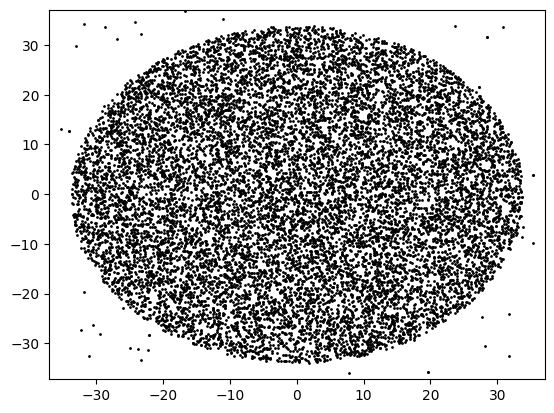

In [15]:
region_good = region.query("gaianir_n < 22").reset_index(drop=True)
obs_good = (
    cluster.observations["gaianir-l-10-(combined)"]
    .query("gaianir_n < 22")
    .sort_values("gaianir_n", ascending=True)
    .reset_index(drop=True)
)

plt.scatter(60**2 * (region_good["l"] - l), 60**2 * (region_good["b"] - b), s=1, c="k")
xlim, ylim = plt.gca().get_xlim(), plt.gca().get_ylim()
plt.scatter(60**2 * (obs_good["l"] - l), 60**2 * (obs_good["b"] - b), s=1, c="k")
plt.gca().set(xlim=xlim, ylim=ylim)
# plt.sca

[(-13.18630465834265, 15.300379003718312),
 (-31.61490324675833, 12.77949498320327)]

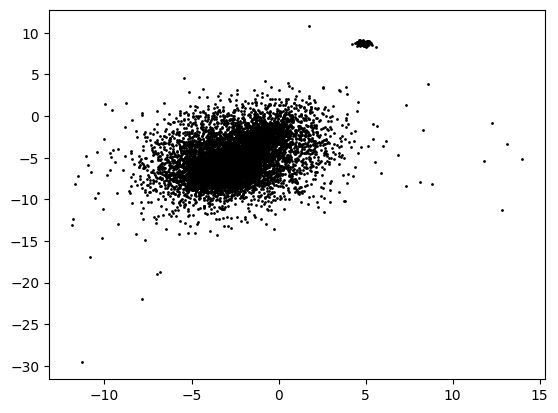

In [16]:
plt.scatter(
    region_good["pmra_gaianir-l_combined"],
    region_good["pmdec_gaianir-l_combined"],
    s=1,
    c="k",
)
xlim, ylim = plt.gca().get_xlim(), plt.gca().get_ylim()
plt.scatter(obs_good["pmra"], obs_good["pmdec"], s=1, c="k")
plt.gca().set(xlim=xlim, ylim=ylim)

HOW ABOUT: I use a fixed background event density, and then also have self-crowding for the cluster? This deals with within-cluster stochasticity AND also removes points nicely. Yay!

In [23]:
crowding_metadata

{'area': 0.0002777777777777778,
 'magnitude_ppfunc': <scipy.interpolate._interpolate.interp1d at 0x741af0133480>,
 'density_param_gaia': np.float64(0.40697938913250575),
 'density_param_gaianir-m': np.float64(1.5705213518893246),
 'density_param_gaianir-l': np.float64(0.3705148332212364)}

In [26]:
observation = cluster.observations["gaianir-l-10-(combined)"]

observation_good = apply_cluster_crowding(
    observation,
    crowding_metadata["density_param_gaianir-l"],
    crowding_metadata["magnitude_ppfunc"],
    "GaiaNIR-L",
)

len(observation_good), len(observation)

(446, 595)

In [27]:
region.keys()

Index(['pop', 'mass_initial', 'age', 'Fe/H_initial', 'mass', 'distance', 'l',
       'b', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius', 'phase',
       'gaia_dr3_g', 'gaia_dr3_bp_true', 'gaia_dr3_rp_true', '2mass_j',
       '2mass_h', '2mass_k', 'label', 'luminosity', 'temperature', 'log_g',
       'radius', 'gaianir_n', 'gaianir_r', 'gaianir_j', 'gaianir_h',
       'gaianir_k', 'extinction_green', 'extinction_zucker', 'extinction',
       'ra', 'dec', 'pmra_true', 'pmdec_true', 'parallax_true',
       'ra_error_gaianir-l', 'dec_error_gaianir-l', 'pmra_error_gaianir-l',
       'pmdec_error_gaianir-l', 'parallax_error_gaianir-l',
       'ra_error_gaianir-m', 'dec_error_gaianir-m', 'pmra_error_gaianir-m',
       'pmdec_error_gaianir-m', 'parallax_error_gaianir-m',
       'ra_error_gaia_dr4', 'dec_error_gaia_dr4', 'pmra_error_gaia_dr4',
       'pmdec_error_gaia_dr4', 'parallax_error_gaia_dr4', 'ra_error_gaia_dr5',
       'dec_error_gaia_dr5', 'pmra_error_gaia_dr5', 'pmdec_error

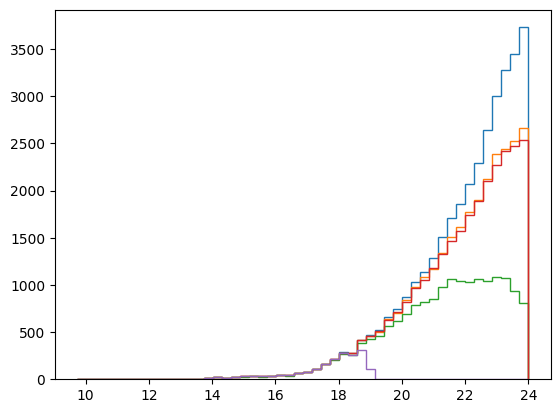

In [35]:
values, bins, _ = plt.hist(region['gaianir_n'], bins=50, histtype="step")
_ = plt.hist(region.query("`uncrowded_gaianir-l`")['gaianir_n'], bins=bins, histtype="step")
_ = plt.hist(region.query("`uncrowded_gaianir-m`")['gaianir_n'], bins=bins, histtype="step")
_ = plt.hist(region.query("uncrowded_gaia")['gaianir_n'], bins=bins, histtype="step")
_ = plt.hist(region.query("uncrowded_gaia and gaia_dr3_g<21")['gaianir_n'], bins=bins, histtype="step")

In [ ]:
region_radiused = region.loc[_radius_crowding(region.sort_values("N", ascending=True), GAIANIR_ANGULAR_RESOLUTION['GaiaNIR-L'])]
len(region_radiused), len(region)

(28476, 33911)

In [ ]:
dat = np.radians(region[['l', 'b']].to_numpy())

neigh = NearestNeighbors(metric="haversine").fit(dat)
distances, indices = neigh.kneighbors(dat, n_neighbors=2)

(array([6.1230e+03, 1.2125e+04, 9.6090e+03, 4.4630e+03, 1.2760e+03,
        2.7200e+02, 3.7000e+01, 5.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([6.91557167e-04, 8.04298432e-02, 1.60168129e-01, 2.39906415e-01,
        3.19644701e-01, 3.99382987e-01, 4.79121273e-01, 5.58859559e-01,
        6.38597845e-01, 7.18336131e-01, 7.98074417e-01]),
 <BarContainer object of 10 artists>)

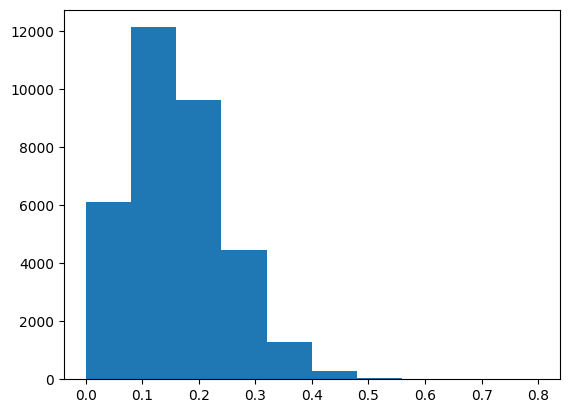

In [ ]:
plt.hist(np.degrees(distances[:, 1])*60**2)

## Aside: are the areas correct?

In [ ]:
area

0.0002777777777777778

In [ ]:
radius = np.sqrt((region['l'] - l)**2 + (region['b'] - b)**2)
np.pi * radius.max()**2

np.float64(0.0002777660078567226)

In [ ]:
area * 60**2

1.0

yes, I just fucked up the squaring there!

In [68]:
region.columns

Index(['pop', 'mass_initial', 'age', 'Fe/H_initial', 'mass', 'distance', 'l',
       'b', 'logL', 'logTeff', 'logg', 'Fe/H_evolved', 'log_radius', 'phase',
       'gaia_dr3_g', 'gaia_dr3_bp_true', 'gaia_dr3_rp_true', '2mass_j',
       '2mass_h', '2mass_k', 'label', 'luminosity', 'temperature', 'log_g',
       'radius', 'gaianir_n', 'gaianir_r', 'gaianir_j', 'gaianir_h',
       'gaianir_k', 'extinction_green', 'extinction_zucker', 'extinction',
       'ra', 'dec', 'pmra_true', 'pmdec_true', 'parallax_true',
       'ra_error_gaianir-l', 'dec_error_gaianir-l', 'pmra_error_gaianir-l',
       'pmdec_error_gaianir-l', 'parallax_error_gaianir-l',
       'ra_error_gaianir-m', 'dec_error_gaianir-m', 'pmra_error_gaianir-m',
       'pmdec_error_gaianir-m', 'parallax_error_gaianir-m',
       'ra_error_gaia_dr4', 'dec_error_gaia_dr4', 'pmra_error_gaia_dr4',
       'pmdec_error_gaia_dr4', 'parallax_error_gaia_dr4', 'ra_error_gaia_dr5',
       'dec_error_gaia_dr5', 'pmra_error_gaia_dr5', 'pmdec_error

## Aside: random sim stuff

### 1. understanding coords again

In [1]:
from gala.potential import MilkyWayPotential
from astropy.coordinates import (
    SkyCoord,
    CylindricalRepresentation,
    CylindricalDifferential,
)
from astropy import units as u

In [2]:
potential = MilkyWayPotential(version="v2")

In [3]:
coords = SkyCoord(l=0 * u.deg, b=0*u.deg, distance=5000*u.pc, frame="galactic")
pos_galactocentric = coords.transform_to("galactocentric")
pos_cylindrical = pos_galactocentric.represent_as("cylindrical")

In [4]:
v_circ = potential.circular_velocity(
    [
        pos_galactocentric.x.to(u.kpc).value,
        pos_galactocentric.y.to(u.kpc).value,
        pos_galactocentric.z.to(u.kpc).value,
    ]
)
v_circ

<Quantity [203.75347669] km / s>

In [7]:
v_phi_angular = (
    -v_circ[0].to(u.km / u.s).value / pos_cylindrical.rho.to(u.km).value * u.rad / u.s
)
coords_full = SkyCoord(
    CylindricalRepresentation(
        rho=pos_cylindrical.rho,
        phi=pos_cylindrical.phi,
        z=pos_cylindrical.z,
        differentials=CylindricalDifferential(
            d_rho=0 * u.km / u.s, d_phi=v_phi_angular, d_z=0 * u.km / u.s
        ),
    ),
    frame="galactocentric",
    # representation_type="cylindrical"
)
# coords_full.transform_to("galactic")
coords_full

<SkyCoord (Galactocentric: galcen_coord=<ICRS Coordinate: (ra, dec) in deg
    (266.4051, -28.936175)>, galcen_distance=8.122 kpc, galcen_v_sun=(12.9, 245.6, 7.78) km / s, z_sun=20.8 pc, roll=0.0 deg): (x, y, z) in pc
    (-3121.98974393, -0.00465103, 8.00242871)
 (v_x, v_y, v_z) in km / s
    (-0.00030354, 203.75347669, 0.)>

In [27]:
coords_full.transform_to("galactic")

<SkyCoord (Galactic): (l, b, distance) in (deg, deg, pc)
    (0., -7.81653119e-15, 5000.)
 (pm_l_cosb, pm_b, radial_velocity) in (mas / yr, mas / yr, km / s)
    (-1.76550185, -0.32962684, -12.88030934)>

In [28]:
coords_full.transform_to("icrs")

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    (266.40498829, -28.93617776, 5000.)
 (pm_ra_cosdec, pm_dec, radial_velocity) in (mas / yr, mas / yr, km / s)
    (-0.63852941, -1.67866936, -12.88030934)>

### 2. wtf is this function failing for

In [11]:
import numpy as np
from gaianir_open_clusters.util import get_circular_orbit_skycoord

In [13]:
get_circular_orbit_skycoord(np.zeros(1), np.zeros(1), np.full(1, 1000))

<SkyCoord (ICRS): (ra, dec, distance) in (deg, deg, pc)
    [(266.40498829, -28.93617776, 1000.)]>

### 3. Combining many clusters

In [92]:
observations = copy.deepcopy(cluster.observations)

keys = []

good_columns = [
    "pmra",
    "pmra_error",
    "pmdec",
    "pmdec_error",
    "parallax",
    "parallax_error",
]

extra_good_columns = [
    "ra",
    "dec",
    "l",
    "b",
    "mass",
    "temperature",
    "luminosity",
    "log_g",
    "gaianir_n",
    "gaianir_r",
    "gaianir_j",
    "gaianir_h",
    "gaianir_k",
    "g_effective_gaia",
]

merged_observation = None
keys = []

for name, observation in observations.items():
    name = (
        name.replace("-10-(combined)", "_combined")
        .replace("-10", "_dr5")
        .replace("-5", "_dr4")
    )
    short_name = name.replace("_combined", "")
    keys.append(short_name)

    if name == "gaianir-l_combined":
        observation = observation[["simulated_id"] + extra_good_columns + good_columns]
    else:
        observation = observation[["simulated_id"] + good_columns]

    observation[short_name] = True
    observation = observation.rename(
        columns={
            "pmra": f"pmra_{name}",
            "pmdec": f"pmdec_{name}",
            "parallax": f"parallax_{name}",
            "pmra_error": f"pmra_error_{name}",
            "pmdec_error": f"pmdec_error_{name}",
            "parallax_error": f"parallax_error_{name}",
        }
    )
    if merged_observation is None:
        merged_observation = observation
    else:
        merged_observation = merged_observation.merge(
            observation,
            on="simulated_id",
            how="left",  # Todo: this assumes gaianir-l is first! Be sure of this
        )
    merged_observation[short_name] = merged_observation[short_name] == True  # noqa: E712


# Apply crowding
key_to_mission = {
    "gaianir-l": "GaiaNIR-L",
    "gaianir-m": "GaiaNIR-M",
    "gaia_dr5": "Gaia",
    "gaia_dr4": "Gaia",
}

merged_observation = merged_observation.sort_values("gaianir_n").reset_index(drop=True)

for key in keys:
    good_stars = merged_observation[key]
    merged_observation.loc[good_stars, key] = apply_cluster_crowding(
        merged_observation.loc[good_stars],
        crowding_metadata,
        key_to_mission[key],
        drop_stars=False,
    )

# merged_observation = (
#     merged_observation.loc[np.any(merged_observation[keys], axis=1)]
#     .sort_values("simulated_id")
#     .reset_index(drop=True)
# )


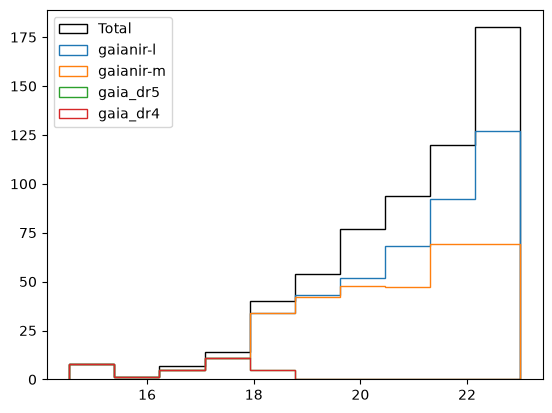

In [93]:
bins = np.linspace(
    merged_observation["gaianir_n"].min(),
    merged_observation["gaianir_n"].max(),
    num=11,
)

plt.hist(
    merged_observation["gaianir_n"],
    histtype="step",
    color="k",
    label="Total",
    bins=bins,
)
for key in keys:
    plt.hist(
        merged_observation.loc[merged_observation[key], "gaianir_n"],
        histtype="step",
        label=key,
        bins=bins,
    )
plt.legend()

In [76]:
crowding_metadata

{'area': 0.0002777777777777778,
 'magnitude_ppfunc': <scipy.interpolate._interpolate.interp1d at 0x7da68e539f40>,
 'density_param_gaia': np.float64(0.4069555801180188),
 'density_param_gaianir-m': np.float64(1.5704294736109212),
 'density_param_gaianir-l': np.float64(0.3704931574478008)}

In [ ]:
merged_observation